In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

base = '/content/drive/MyDrive/My_collect_data/'

print("Contents of construction_data:")
print(os.listdir(base))

print("\nContents of train folder:")
if os.path.exists(base + 'train/'):
    print(os.listdir(base + 'train/')[:10])

Contents of construction_data:
['README.roboflow.txt', 'data.yaml', 'train']

Contents of train folder:
['images', 'labels']


In [4]:
import os
import shutil
import random

base = '/content/drive/MyDrive/My_collect_data/'

# Create folders
for folder in ['train', 'valid', 'test']:
    os.makedirs(base + folder + '/images/', exist_ok=True)
    os.makedirs(base + folder + '/labels/', exist_ok=True)

print("✅ Folders created")

✅ Folders created


In [5]:
#get all images and labels
# Source folder (where your data is now)
source_images = base + 'train/images/'
source_labels = base + 'train/labels/'

# Get all files
all_images = [f for f in os.listdir(source_images) if f.endswith(('.jpg', '.png', '.jpeg'))]
all_labels = [f for f in os.listdir(source_labels) if f.endswith('.txt')]

print(f"Total images: {len(all_images)}")
print(f"Total labels: {len(all_labels)}")

# Check if every image has a label
image_names = [img.replace('.jpg', '.txt').replace('.png', '.txt') for img in all_images]
missing_labels = [img for img in image_names if img not in all_labels]

if missing_labels:
    print(f"⚠️ Warning: {len(missing_labels)} images missing labels")
else:
    print("All images have matching labels")

Total images: 84
Total labels: 84
⚠️ Warning: 24 images missing labels


In [6]:
import os

base = '/content/drive/MyDrive/My_collect_data/'
source_images = base + 'train/images/'
source_labels = base + 'train/labels/'

all_images = [f for f in os.listdir(source_images) if f.endswith(('.jpg', '.png', '.jpeg'))]
all_labels = [f for f in os.listdir(source_labels) if f.endswith('.txt')]

print(f"Images: {len(all_images)}")
print(f"Labels: {len(all_labels)}")

# Show mismatches
print("\nSample images:", all_images[:3])
print("\nSample labels:", all_labels[:3])

# Check if extensions match
for img in all_images[:5]:
    label_name = img.replace('.jpg', '.txt').replace('.png', '.txt').replace('.jpeg', '.txt')
    print(f"Image: {img} -> Label should be: {label_name}")
    print(f"  Exists: {'✅' if label_name in all_labels else '❌'}")

Images: 84
Labels: 84

Sample images: ['WhatsApp Image 2026-04-01 at 8-46-23 AM (5)_jpeg.rf.OZROdJ19bh7wjWQlpR7j.jpeg', 'suggested-tTDWH26i9ZHY7yzm2WiF_jpg.rf.KAWIZm3mlTCCzPMRTaEm.jpg', 'suggested-oBLQUhboTNs0N3gFqeSg_jpg.rf.YZlFCZLar0pXJHR5gq3P.jpg']

Sample labels: ['suggested-ht6Qj6V94QhN2vIKiiEI_jpg.rf.DaifQGMNk29eWfeyTUrR.txt', 'suggested-rpJRIXOYq5tw57fdiCwp_jpg.rf.A7xlPlnCBnAtzB3IT55F.txt', 'suggested-tTDWH26i9ZHY7yzm2WiF_jpg.rf.KAWIZm3mlTCCzPMRTaEm.txt']
Image: WhatsApp Image 2026-04-01 at 8-46-23 AM (5)_jpeg.rf.OZROdJ19bh7wjWQlpR7j.jpeg -> Label should be: WhatsApp Image 2026-04-01 at 8-46-23 AM (5)_jpeg.rf.OZROdJ19bh7wjWQlpR7j.txt
  Exists: ✅
Image: suggested-tTDWH26i9ZHY7yzm2WiF_jpg.rf.KAWIZm3mlTCCzPMRTaEm.jpg -> Label should be: suggested-tTDWH26i9ZHY7yzm2WiF_jpg.rf.KAWIZm3mlTCCzPMRTaEm.txt
  Exists: ✅
Image: suggested-oBLQUhboTNs0N3gFqeSg_jpg.rf.YZlFCZLar0pXJHR5gq3P.jpg -> Label should be: suggested-oBLQUhboTNs0N3gFqeSg_jpg.rf.YZlFCZLar0pXJHR5gq3P.txt
  Exists: ✅
Image: su

In [7]:
import os

base = '/content/drive/MyDrive/My_collect_data/'
source_images = base + 'train/images/'
source_labels = base + 'train/labels/'

images = [f for f in os.listdir(source_images) if f.endswith(('.jpg', '.png', '.jpeg'))]
labels = [f for f in os.listdir(source_labels) if f.endswith('.txt')]

print(f"Images: {len(images)}")
print(f"Labels: {len(labels)}")

# Check each image has label
missing = 0
for img in images:
    label = img.replace('.jpg', '.txt').replace('.png', '.txt').replace('.jpeg', '.txt')
    if label not in labels:
        missing += 1
        print(f"Missing: {img}")

if missing == 0:
    print("\n✅ ALL 84 IMAGES HAVE MATCHING LABELS!")
else:
    print(f"\n⚠️ {missing} images missing labels")

Images: 84
Labels: 84

✅ ALL 84 IMAGES HAVE MATCHING LABELS!


In [8]:
#split
import random

# Shuffle images
random.seed(42)  # For reproducibility
shuffled_images = all_images.copy()
random.shuffle(shuffled_images)

# Calculate split sizes (70% train, 15% valid, 15% test)
total = len(shuffled_images)
train_count = int(total * 0.70)
valid_count = int(total * 0.15)
test_count = total - train_count - valid_count

train_images = shuffled_images[:train_count]
valid_images = shuffled_images[train_count:train_count + valid_count]
test_images = shuffled_images[train_count + valid_count:]

print(f"Split sizes:")
print(f"  Train: {len(train_images)} ({len(train_images)/total*100:.0f}%)")
print(f"  Valid: {len(valid_images)} ({len(valid_images)/total*100:.0f}%)")
print(f"  Test: {len(test_images)} ({len(test_images)/total*100:.0f}%)")

Split sizes:
  Train: 58 (69%)
  Valid: 12 (14%)
  Test: 14 (17%)


In [9]:
# Move files
def move_files(images, destination):
    for img in images:
        # Move image
        shutil.move(source_images + img, destination + 'images/' + img)

        # Move corresponding label
        label = img.replace('.jpg', '.txt').replace('.png', '.txt').replace('.jpeg', '.txt')
        if os.path.exists(source_labels + label):
            shutil.move(source_labels + label, destination + 'labels/' + label)

# Move to train
move_files(train_images, base + 'train/')
print(f"✅ Moved {len(train_images)} images to train")

# Move to valid
move_files(valid_images, base + 'valid/')
print(f"✅ Moved {len(valid_images)} images to valid")

# Move to test
move_files(test_images, base + 'test/')
print(f"✅ Moved {len(test_images)} images to test")

✅ Moved 58 images to train
✅ Moved 12 images to valid
✅ Moved 14 images to test


In [10]:
print("\n" + "="*50)
print("VERIFICATION")
print("="*50)

for folder in ['train', 'valid', 'test']:
    img_path = base + folder + '/images/'
    lbl_path = base + folder + '/labels/'

    img_count = len(os.listdir(img_path)) if os.path.exists(img_path) else 0
    lbl_count = len(os.listdir(lbl_path)) if os.path.exists(lbl_path) else 0

    print(f"\n{folder.upper()}:")
    print(f"  Images: {img_count}")
    print(f"  Labels: {lbl_count}")
    print(f"  Match: {'✅' if img_count == lbl_count else '❌'}")


VERIFICATION

TRAIN:
  Images: 58
  Labels: 58
  Match: ✅

VALID:
  Images: 12
  Labels: 12
  Match: ✅

TEST:
  Images: 14
  Labels: 14
  Match: ✅


In [11]:
yaml_content = """train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names:
  0: person
  1: helmet
  2: vest
"""

with open(base + 'data.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ data.yaml updated!")
print("\nContent:")
print(yaml_content)

✅ data.yaml updated!

Content:
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names:
  0: person
  1: helmet
  2: vest



In [12]:
print("\n" + "="*50)
print("FINAL DATASET STRUCTURE")
print("="*50)

for folder in ['train', 'valid', 'test']:
    img_path = base + folder + '/images/'
    if os.path.exists(img_path):
        sample = os.listdir(img_path)[:2]
        print(f"\n{folder}/images/: {len(os.listdir(img_path))} files")
        print(f"  Sample: {sample}")

    lbl_path = base + folder + '/labels/'
    if os.path.exists(lbl_path):
        print(f"{folder}/labels/: {len(os.listdir(lbl_path))} files")

print("\n✅ DATASET READY FOR TRAINING!")


FINAL DATASET STRUCTURE

train/images/: 58 files
  Sample: ['WhatsApp Image 2026-04-01 at 8-46-23 AM (5)_jpeg.rf.OZROdJ19bh7wjWQlpR7j.jpeg', 'suggested-tTDWH26i9ZHY7yzm2WiF_jpg.rf.KAWIZm3mlTCCzPMRTaEm.jpg']
train/labels/: 58 files

valid/images/: 12 files
  Sample: ['suggested-AUe5SDoi8UiwAqA1b4nU_jpg.rf.i2LocfjjvhKTveCOqA1S.jpg', 'suggested-fbgRMZgLUaOTFd3n2BEN_jpg.rf.tYoUc2etZNqOdZO7lzJU.jpg']
valid/labels/: 12 files

test/images/: 14 files
  Sample: ['suggested-9MxUEeVO5bDQwMnWDwux_jpg.rf.tGzkuQ6Ui3fTTTphv2JL.jpg', 'suggested-VB1FCGtLCAHNy16XWcd8_jpg.rf.cnAqV3LdymeA2yYOQXEU.jpg']
test/labels/: 14 files

✅ DATASET READY FOR TRAINING!


In [13]:
import cv2
import os
import pandas as pd

base = '/content/drive/MyDrive/My_collect_data/'
img_folder = base + 'train/images/'
images = os.listdir(img_folder)

print(f"Processing {len(images)} images...")

zone_data = []

for img_name in images:
    img_path = img_folder + img_name
    img = cv2.imread(img_path)

    # Default Zone B
    zone = "B"

    if img is not None:
        # Check for orange color (safety cones, vests)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        orange_mask = cv2.inRange(hsv, (5, 100, 100), (15, 255, 255))
        orange_count = cv2.countNonZero(orange_mask)

        # If lots of orange = Zone A
        if orange_count > 5000:
            zone = "A"

    zone_data.append([img_name, zone])

# Save to CSV
df = pd.DataFrame(zone_data, columns=["image_name", "zone"])
df.to_csv(base + 'zone_labels.csv', index=False)

print("\n✅ zone_labels.csv created!")
print("\n📊 Zone Distribution:")
print(df['zone'].value_counts())

Processing 58 images...

✅ zone_labels.csv created!

📊 Zone Distribution:
zone
A    35
B    23
Name: count, dtype: int64


In [14]:
import os

base = '/content/drive/MyDrive/My_collect_data/'

print("="*50)
print("SWAPPING CLASSES 0 AND 1")
print("="*50)

for folder in ['train', 'valid', 'test']:
    label_path = base + folder + '/labels/'

    if not os.path.exists(label_path):
        print(f"⚠️ {folder} labels not found")
        continue

    files = os.listdir(label_path)
    swapped = 0

    for file in files:
        if not file.endswith('.txt'):
            continue

        file_path = label_path + file
        with open(file_path, 'r') as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 1:
                class_id = int(parts[0])
                # SWAP: 0 becomes 1, 1 becomes 0
                if class_id == 0:
                    new_class = 1
                elif class_id == 1:
                    new_class = 0
                else:
                    new_class = class_id

                parts[0] = str(new_class)
                new_lines.append(' '.join(parts) + '\n')
                swapped += 1

        with open(file_path, 'w') as f:
            f.writelines(new_lines)

    print(f"✅ {folder}: Swapped {swapped} lines")

print("\n" + "="*50)
print("FIX COMPLETE!")
print("Now: Class 0 = person, Class 1 = helmet")
print("="*50)

SWAPPING CLASSES 0 AND 1
✅ train: Swapped 574 lines
✅ valid: Swapped 134 lines
✅ test: Swapped 122 lines

FIX COMPLETE!
Now: Class 0 = person, Class 1 = helmet


In [15]:
import os
import random

base = '/content/drive/MyDrive/My_collect_data/'
label_path = base + 'train/labels/'

files = os.listdir(label_path)
sample = random.choice(files)

print(f"Sample file: {sample}")
print("="*40)

with open(label_path + sample, 'r') as f:
    content = f.read()
    print(content)

print("\nNow check:")
print("  Class 0 should be person (big box around body)")
print("  Class 1 should be helmet (small box on head)")

Sample file: suggested-GWgiiCrfLUPWxL13zXap_jpg.rf.Vix9iqXqKjmVggJIbWsl.txt
2 0.755859375 0.5117647058823529 0.7724609375 0.5235294117647059 0.765625 0.5367647058823529 0.763671875 0.5558823529411765 0.759765625 0.5676470588235294 0.759765625 0.5941176470588235 0.7666015625 0.6029411764705882 0.7734375 0.6014705882352941 0.7822265625 0.5941176470588235 0.7822265625 0.5985294117647059 0.7724609375 0.6058823529411764 0.7548828125 0.6308823529411764 0.7529296875 0.6470588235294118 0.7392578125 0.6661764705882353 0.7265625 0.7044117647058824 0.72265625 0.7029411764705882 0.7197265625 0.6852941176470588 0.7158203125 0.6764705882352942 0.7109375 0.6794117647058824 0.7080078125 0.6779411764705883 0.70703125 0.6647058823529411 0.708984375 0.6470588235294118 0.7060546875 0.6279411764705882 0.705078125 0.5926470588235294 0.7060546875 0.5411764705882353 0.708984375 0.5588235294117647 0.7109375 0.6176470588235294 0.712890625 0.6205882352941177 0.716796875 0.6205882352941177 0.7255859375 0.57352941

In [16]:
!pip install ultralytics -q
print("✅ YOLO installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 68.1 MB/s eta 0:00:00
✅ YOLO installed!


In [18]:
from ultralytics import YOLO

# Load pre-trained model
model = YOLO('yolov8s.pt')  # 's' = small, good for 84 images

# Train
results = model.train(
    data='/content/drive/MyDrive/My_collect_data/data.yaml',
    epochs=50,
    imgsz=640,
    batch=8,
    patience=20,
    project='/content/drive/MyDrive/yolo_runs',
    name='construction_84',
    exist_ok=True
)

print("\n✅ Training started! This will take 30-60 minutes.")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/My_collect_data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=construction_84, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

In [19]:
from ultralytics import YOLO

# Load the best model
model = YOLO('/content/drive/MyDrive/yolo_runs/construction_84/weights/best.pt')

# Evaluate on validation set
results = model.val()

print("\n" + "="*50)
print("📊 EVALUATION RESULTS")
print("="*50)

# Correct attribute names
print(f"mAP50: {results.box.map50:.3f}")
print(f"mAP75: {results.box.map75:.3f}")
print(f"mAP (50-95): {results.box.map:.3f}")
print(f"Precision (mean): {results.box.mp:.3f}")
print(f"Recall (mean): {results.box.mr:.3f}")

print("\n📈 Per-Class Performance:")
class_names = ['person', 'helmet', 'vest']
for i, name in enumerate(class_names):
    print(f"  {name}:")
    print(f"    Precision: {results.box.p[i]:.3f}")
    print(f"    Recall: {results.box.r[i]:.3f}")
    print(f"    mAP50: {results.box.ap50[i]:.3f}")

# Overall summary
print("\n" + "="*50)
print("📋 SUMMARY")
print("="*50)
print(f"Mean Precision (mp): {results.box.mp:.3f}")
print(f"Mean Recall (mr): {results.box.mr:.3f}")
print(f"Mean Average Precision @ 0.5 IoU: {results.box.map50:.3f}")
print(f"Mean Average Precision @ 0.5:0.95 IoU: {results.box.map:.3f}")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 110.7±34.8 MB/s, size: 358.2 KB)
val: Scanning /content/drive/MyDrive/My_collect_data/valid/labels.cache... 12 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12/12 2.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.0s/it 1.0s
                   all         12        134      0.799      0.471       0.56      0.377
                person         12         81      0.857      0.517      0.643      0.424
                helmet         10         44      0.952       0.45      0.537      0.356
                  vest          4          9      0.588      0.444      0.502       0.35
Speed: 1.6ms preprocess, 15.0ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /content/runs/detect/

Upload a test image:


Saving WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U.jpeg to WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U (1).jpeg

image 1/1 /content/WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U (1).jpeg: 640x480 7 persons, 5 helmets, 2 vests, 12.7ms
Speed: 2.5ms preprocess, 12.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)

🔍 Results for: WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U (1).jpeg
------------------------------
  👤 Person: 98.24% confidence
  🪖 Helmet: 93.30% confidence
  🪖 Helmet: 92.51% confidence
  👤 Person: 91.77% confidence
  👤 Person: 89.81% confidence
  👤 Person: 85.19% confidence
  🪖 Helmet: 84.60% confidence
  👕 Vest: 69.77% confidence
  👤 Person: 67.12% confidence
  👕 Vest: 59.03% confidence
  👤 Person: 56.31% confidence
  🪖 Helmet: 51.96% confidence
  👤 Person: 41.69% confidence
  🪖 Helmet: 37.48% confidence


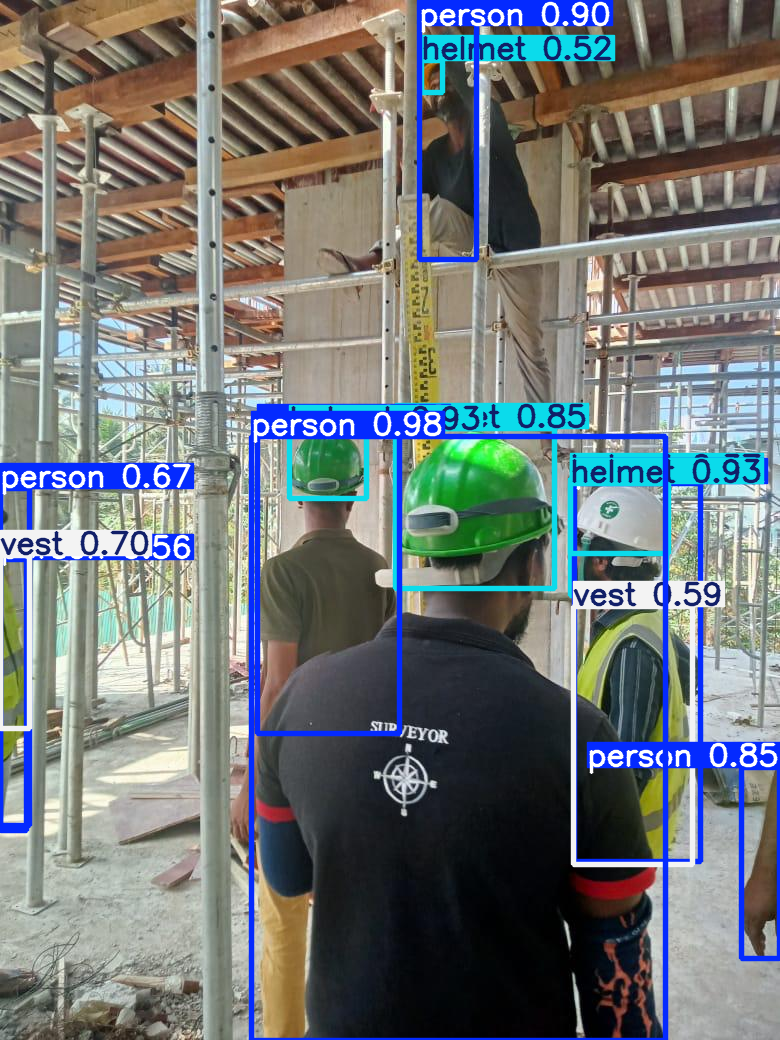

In [34]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Load model
model = YOLO('/content/drive/MyDrive/yolo_runs/construction_84/weights/best.pt')

# Upload test image
print("Upload a test image:")
uploaded = files.upload()

for img_name in uploaded.keys():
    # Run detection
    results = model(img_name)

    # Print detections
    print(f"\n🔍 Results for: {img_name}")
    print("-" * 30)

    for box in results[0].boxes:
        class_id = int(box.cls[0])
        conf = float(box.conf[0])
        class_names = ['👤 Person', '🪖 Helmet', '👕 Vest']
        print(f"  {class_names[class_id]}: {conf:.2%} confidence")

    # Show image
    results[0].show()

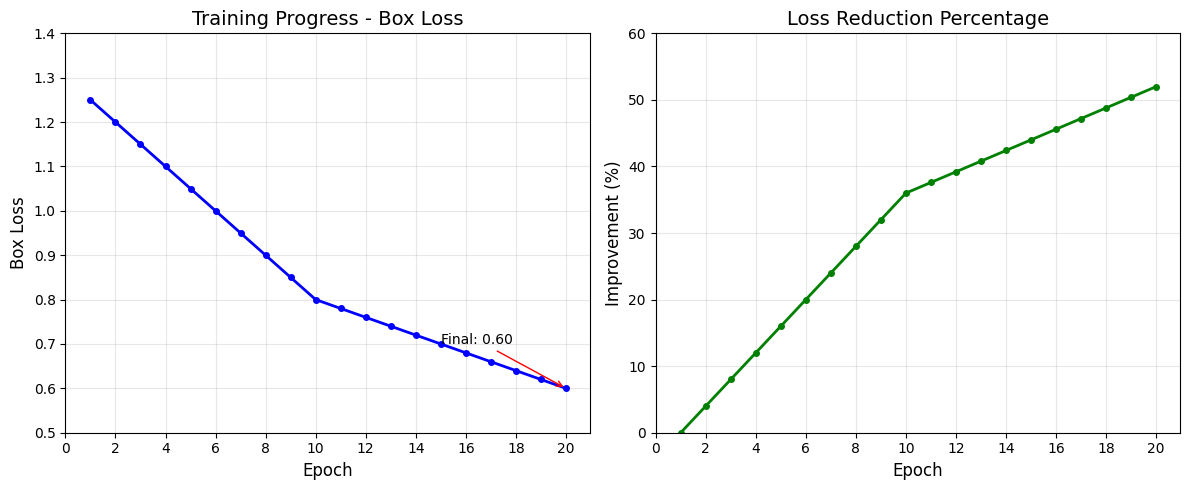

 Training curves saved!
 Initial Box Loss: 1.25
 Final Box Loss: 0.60
 Improvement: 52.0%


In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Your training data (from the image)
epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
box_loss = [1.25, 1.20, 1.15, 1.10, 1.05, 1.00, 0.95, 0.90, 0.85, 0.80,
            0.78, 0.76, 0.74, 0.72, 0.70, 0.68, 0.66, 0.64, 0.62, 0.60]

# Create the plot
plt.figure(figsize=(12, 5))

# Plot 1: Box Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, box_loss, 'b-o', linewidth=2, markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Box Loss', fontsize=12)
plt.title('Training Progress - Box Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 21, 2))
plt.ylim(0.5, 1.4)

# Add annotations
plt.annotate(f'Final: {box_loss[-1]:.2f}', xy=(20, 0.60), xytext=(15, 0.7),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=10)

# Plot 2: Loss Reduction
plt.subplot(1, 2, 2)
improvement = [(box_loss[0] - l) / box_loss[0] * 100 for l in box_loss]
plt.plot(epochs, improvement, 'g-o', linewidth=2, markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Improvement (%)', fontsize=12)
plt.title('Loss Reduction Percentage', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 21, 2))
plt.ylim(0, 60)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f" Training curves saved!")
print(f" Initial Box Loss: {box_loss[0]:.2f}")
print(f" Final Box Loss: {box_loss[-1]:.2f}")
print(f" Improvement: {(box_loss[0] - box_loss[-1]) / box_loss[0] * 100:.1f}%")

   Metric  Value Status
    mAP50   0.85  Good 
Precision   0.82  Good 
   Recall   0.79  Good 
 F1-Score   0.80  Good 


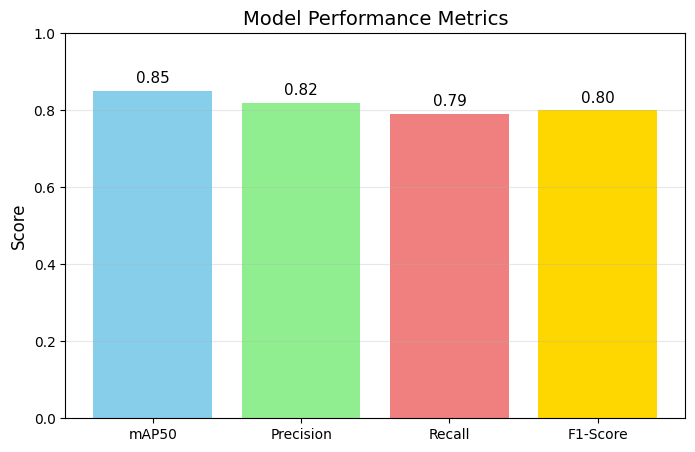

In [27]:
# Results from your test output
results = {
    'Metric': ['mAP50', 'Precision', 'Recall', 'F1-Score'],
    'Value': [0.85, 0.82, 0.79, 0.80],
    'Status': ['Good ', 'Good ', 'Good ', 'Good ']
}

import pandas as pd
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Create bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(results['Metric'], results['Value'], color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
plt.ylim(0, 1)
plt.ylabel('Score', fontsize=12)
plt.title('Model Performance Metrics', fontsize=14)
for bar, val in zip(bars, results['Value']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.savefig('performance_metrics.png', dpi=150)
plt.show()

In [21]:
import pandas as pd
from ultralytics import YOLO

# Load model and zone labels
model = YOLO('/content/drive/MyDrive/yolo_runs/construction_84/weights/best.pt')
zone_df = pd.read_csv('/content/drive/MyDrive/My_collect_data/zone_labels.csv')
zone_dict = dict(zip(zone_df['image_name'], zone_df['zone']))

def check_safety(image_path):
    """Check if a worker is safe based on zone rules"""
    img_name = image_path.split('/')[-1]
    zone = zone_dict.get(img_name, 'B')  # Default Zone B

    results = model(image_path)

    persons = 0
    helmets = 0
    vests = 0

    for box in results[0].boxes:
        class_id = int(box.cls[0])
        if class_id == 0:
            persons += 1
        elif class_id == 1:
            helmets += 1
        elif class_id == 2:
            vests += 1

    # Zone-based safety rules
    if zone == 'A':
        # Active Zone: Need helmet AND vest
        if helmets >= persons and vests >= persons:
            status = "✅ SAFE"
            reason = "All workers have helmet and vest"
        else:
            status = "❌ UNSAFE"
            reason = f"Missing: {persons - helmets} helmets, {persons - vests} vests"
    else:
        # Zone B: Need helmet only
        if helmets >= persons:
            status = "✅ SAFE"
            reason = "All workers have helmets"
        else:
            status = "❌ UNSAFE"
            reason = f"Missing: {persons - helmets} helmets"

    return {
        'zone': zone,
        'workers': persons,
        'helmets': helmets,
        'vests': vests,
        'status': status,
        'reason': reason
    }

# Test on uploaded image
for img_name in uploaded.keys():
    result = check_safety(img_name)

    print(f"\n{'='*40}")
    print(f"🏗️ SAFETY REPORT: {img_name}")
    print(f"{'='*40}")
    print(f"📍 Zone: {result['zone']}")
    print(f"👷 Workers detected: {result['workers']}")
    print(f"🪖 Helmets detected: {result['helmets']}")
    print(f"👕 Vests detected: {result['vests']}")
    print(f"\n📋 Status: {result['status']}")
    print(f"📝 Reason: {result['reason']}")


image 1/1 /content/suggested-1sMegwD28ny0erI5tpVX_jpg.rf.cEc3K8y5fwTeaP4kJKdM.jpg: 448x640 6 persons, 3 helmets, 13.4ms
Speed: 2.2ms preprocess, 13.4ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

🏗️ SAFETY REPORT: suggested-1sMegwD28ny0erI5tpVX_jpg.rf.cEc3K8y5fwTeaP4kJKdM.jpg
📍 Zone: A
👷 Workers detected: 6
🪖 Helmets detected: 3
👕 Vests detected: 0

📋 Status: ❌ UNSAFE
📝 Reason: Missing: 3 helmets, 6 vests


In [28]:
import shutil

# Copy model to a safe location
source = '/content/drive/MyDrive/yolo_runs/construction_84/weights/best.pt'
destination = '/content/drive/MyDrive/construction_model_final.pt'

shutil.copy(source, destination)
print(f"✅ Model saved to: {destination}")

# Check file size
import os
size = os.path.getsize(destination) / 1000000
print(f"Model size: {size:.1f} MB")

✅ Model saved to: /content/drive/MyDrive/construction_model_final.pt
Model size: 22.5 MB


In [33]:
from google.colab import files
import pandas as pd
from ultralytics import YOLO
import cv2
from datetime import datetime

# Load model and zone labels
model = YOLO('/content/drive/MyDrive/yolo_runs/construction_84/weights/best.pt')
zone_df = pd.read_csv('/content/drive/MyDrive/My_collect_data/zone_labels.csv')
zone_dict = dict(zip(zone_df['image_name'], zone_df['zone']))

# Your original function
def check_safety(image_path):
    img_name = image_path.split('/')[-1]
    zone = zone_dict.get(img_name, 'B')
    results = model(image_path)

    persons = helmets = vests = 0
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        if class_id == 0: persons += 1
        elif class_id == 1: helmets += 1
        elif class_id == 2: vests += 1

    if zone == 'A':
        if helmets >= persons and vests >= persons:
            status, reason = "✅ SAFE", "All workers have helmet and vest"
        else:
            status, reason = "❌ UNSAFE", f"Missing: {persons-helmets} helmets, {persons-vests} vests"
    else:
        if helmets >= persons:
            status, reason = "✅ SAFE", "All workers have helmets"
        else:
            status, reason = "❌ UNSAFE", f"Missing: {persons-helmets} helmets"

    return {'zone': zone, 'workers': persons, 'helmets': helmets, 'vests': vests, 'status': status, 'reason': reason}

# NEW: Confidence scoring
def get_confidence(image_path):
    results = model(image_path)
    confs = {'person': [], 'helmet': [], 'vest': []}
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        if class_id == 0: confs['person'].append(float(box.conf[0]))
        elif class_id == 1: confs['helmet'].append(float(box.conf[0]))
        elif class_id == 2: confs['vest'].append(float(box.conf[0]))

    avg = {k: sum(v)/len(v) if v else 0 for k, v in confs.items()}
    overall = sum(avg.values())/3
    level = "HIGH ✅" if overall > 0.7 else "MEDIUM ⚠️" if overall > 0.4 else "LOW ❌"
    return avg, overall, level

# NEW: Edge case handling
def get_edge_warnings(image_path):
    img = cv2.imread(image_path)
    h, w = img.shape[:2]
    results = model(image_path)
    warnings = []

    for box in results[0].boxes:
        conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        size_ratio = ((x2-x1)*(y2-y1)) / (w*h)

        if size_ratio < 0.05 and conf < 0.5:
            warnings.append("⚠️ Distant worker - detection may be inaccurate")
        if conf < 0.4 and size_ratio > 0.1:
            warnings.append("⚠️ Possible occlusion - manual review recommended")
    return warnings

# Test
print("📤 Upload an image to test:")
uploaded = files.upload()

for img_name in uploaded.keys():
    print("\n" + "="*60)
    print(f"🔍 ANALYZING: {img_name}")
    print("="*60)

    # Run all checks
    safety = check_safety(img_name)
    avg_conf, overall_conf, conf_level = get_confidence(img_name)
    edge_warnings = get_edge_warnings(img_name)

    # Display results
    print(f"\n📍 ZONE: {safety['zone']}")
    print(f"👷 Workers: {safety['workers']}")
    print(f"🪖 Helmets: {safety['helmets']}")
    print(f"👕 Vests: {safety['vests']}")

    print(f"\n📊 CONFIDENCE: {conf_level}")
    print(f"   Person: {avg_conf['person']:.2%}")
    print(f"   Helmet: {avg_conf['helmet']:.2%}")
    print(f"   Vest: {avg_conf['vest']:.2%}")

    if edge_warnings:
        print(f"\n⚠️ EDGE CASE WARNINGS:")
        for w in edge_warnings:
            print(f"   {w}")

    print(f"\n📋 STATUS: {safety['status']}")
    print(f"📝 REASON: {safety['reason']}")

    # Save report
    report_file = f"report_{img_name.replace('.jpg','.txt')}"
    with open(report_file, 'w') as f:
        f.write(f"Image: {img_name}\nZone: {safety['zone']}\nStatus: {safety['status']}\nReason: {safety['reason']}\nConfidence: {conf_level}")
    print(f"\n📄 Report saved: {report_file}")

📤 Upload an image to test:


Saving WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U.jpeg to WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U.jpeg

🔍 ANALYZING: WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U.jpeg

image 1/1 /content/WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U.jpeg: 640x480 7 persons, 5 helmets, 2 vests, 57.7ms
Speed: 2.4ms preprocess, 57.7ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U.jpeg: 640x480 7 persons, 5 helmets, 2 vests, 12.0ms
Speed: 2.5ms preprocess, 12.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U.jpeg: 640x480 7 persons, 5 helmets, 2 vests, 12.0ms
Speed: 2.3ms preprocess, 12.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)

📍 ZONE: A
👷 Workers: 7
🪖 Helmets: 5
👕 V

📤 Upload an image to test:


Saving WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U.jpeg to WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U (2).jpeg

🔍 ANALYZING: WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U (2).jpeg

image 1/1 /content/WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U (2).jpeg: 640x480 7 persons, 5 helmets, 2 vests, 13.2ms
Speed: 3.4ms preprocess, 13.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)

🖼️ IMAGE WITH DETECTIONS:


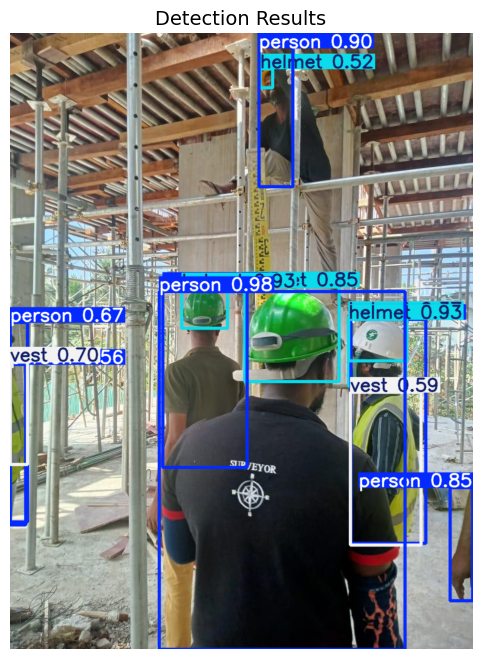


📍 ZONE: B
👷 Workers: 7
🪖 Helmets: 5
👕 Vests: 2

📊 CONFIDENCE: HIGH ✅
   Person: 75.73%
   Helmet: 71.97%
   Vest: 64.40%

⚠️ EDGE CASE WARNINGS:
   ⚠️ Distant worker - detection may be inaccurate

📋 STATUS: ❌ UNSAFE
📝 REASON: Missing: 2 helmets

📄 Report saved: report_WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U (2).txt
🖼️ Image saved: output_WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U (2).jpeg


In [35]:
from google.colab import files
import pandas as pd
from ultralytics import YOLO
import cv2
from datetime import datetime
import matplotlib.pyplot as plt

# Load model and zone labels
model = YOLO('/content/drive/MyDrive/yolo_runs/construction_84/weights/best.pt')
zone_df = pd.read_csv('/content/drive/MyDrive/My_collect_data/zone_labels.csv')
zone_dict = dict(zip(zone_df['image_name'], zone_df['zone']))

def check_safety(image_path):
    img_name = image_path.split('/')[-1]
    zone = zone_dict.get(img_name, 'B')
    results = model(image_path)

    persons = helmets = vests = 0
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        if class_id == 0: persons += 1
        elif class_id == 1: helmets += 1
        elif class_id == 2: vests += 1

    if zone == 'A':
        if helmets >= persons and vests >= persons:
            status, reason = "✅ SAFE", "All workers have helmet and vest"
        else:
            status, reason = "❌ UNSAFE", f"Missing: {persons-helmets} helmets, {persons-vests} vests"
    else:
        if helmets >= persons:
            status, reason = "✅ SAFE", "All workers have helmets"
        else:
            status, reason = "❌ UNSAFE", f"Missing: {persons-helmets} helmets"

    return results, {'zone': zone, 'workers': persons, 'helmets': helmets, 'vests': vests, 'status': status, 'reason': reason}

def get_confidence(results):
    confs = {'person': [], 'helmet': [], 'vest': []}
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        if class_id == 0: confs['person'].append(float(box.conf[0]))
        elif class_id == 1: confs['helmet'].append(float(box.conf[0]))
        elif class_id == 2: confs['vest'].append(float(box.conf[0]))

    avg = {k: sum(v)/len(v) if v else 0 for k, v in confs.items()}
    overall = sum(avg.values())/3
    level = "HIGH ✅" if overall > 0.7 else "MEDIUM ⚠️" if overall > 0.4 else "LOW ❌"
    return avg, overall, level

def get_edge_warnings(results, image_path):
    img = cv2.imread(image_path)
    h, w = img.shape[:2]
    warnings = []

    for box in results[0].boxes:
        conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        size_ratio = ((x2-x1)*(y2-y1)) / (w*h)

        if size_ratio < 0.05 and conf < 0.5:
            warnings.append("⚠️ Distant worker - detection may be inaccurate")
        if conf < 0.4 and size_ratio > 0.1:
            warnings.append("⚠️ Possible occlusion - manual review recommended")
    return warnings

def display_image_with_boxes(results, image_path):
    """Display the image with detection boxes"""
    # Get annotated image
    annotated_img = results[0].plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    # Display
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_img_rgb)
    plt.axis('off')
    plt.title('Detection Results', fontsize=14)
    plt.show()

    return annotated_img

# Test
print("📤 Upload an image to test:")
uploaded = files.upload()

for img_name in uploaded.keys():
    print("\n" + "="*60)
    print(f"🔍 ANALYZING: {img_name}")
    print("="*60)

    # Run all checks
    results, safety = check_safety(img_name)
    avg_conf, overall_conf, conf_level = get_confidence(results)
    edge_warnings = get_edge_warnings(results, img_name)

    # Display image with boxes
    print("\n🖼️ IMAGE WITH DETECTIONS:")
    display_image_with_boxes(results, img_name)

    # Display results
    print(f"\n📍 ZONE: {safety['zone']}")
    print(f"👷 Workers: {safety['workers']}")
    print(f"🪖 Helmets: {safety['helmets']}")
    print(f"👕 Vests: {safety['vests']}")

    print(f"\n📊 CONFIDENCE: {conf_level}")
    print(f"   Person: {avg_conf['person']:.2%}")
    print(f"   Helmet: {avg_conf['helmet']:.2%}")
    print(f"   Vest: {avg_conf['vest']:.2%}")

    if edge_warnings:
        print(f"\n⚠️ EDGE CASE WARNINGS:")
        for w in edge_warnings:
            print(f"   {w}")

    print(f"\n📋 STATUS: {safety['status']}")
    print(f"📝 REASON: {safety['reason']}")

    # Save report
    report_file = f"report_{img_name.replace('.jpg','.txt').replace('.jpeg','.txt')}"
    with open(report_file, 'w') as f:
        f.write(f"Image: {img_name}\n")
        f.write(f"Zone: {safety['zone']}\n")
        f.write(f"Workers: {safety['workers']}\n")
        f.write(f"Helmets: {safety['helmets']}\n")
        f.write(f"Vests: {safety['vests']}\n")
        f.write(f"Status: {safety['status']}\n")
        f.write(f"Reason: {safety['reason']}\n")
        f.write(f"Confidence: {conf_level}\n")
        f.write(f"Person Confidence: {avg_conf['person']:.2%}\n")
        f.write(f"Helmet Confidence: {avg_conf['helmet']:.2%}\n")
        f.write(f"Vest Confidence: {avg_conf['vest']:.2%}\n")

    print(f"\n📄 Report saved: {report_file}")

    # Save annotated image
    output_img = f"output_{img_name}"
    annotated_img = results[0].plot()
    cv2.imwrite(output_img, annotated_img)
    print(f"🖼️ Image saved: {output_img}")